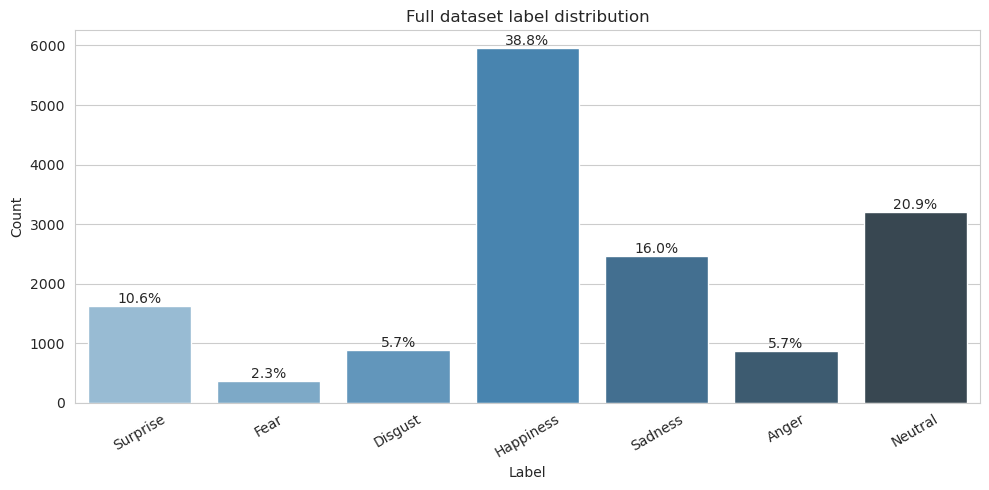

,count,percent
label,,
Surprise,1619,10.55
Fear,355,2.31
Disgust,877,5.72
Happiness,5957,38.84
Sadness,2460,16.04
Anger,867,5.65
Neutral,3204,20.89


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

root = Path('datasets/raf-db')
label_names = {
    1: 'Surprise',
    2: 'Fear',
    3: 'Disgust',
    4: 'Happiness',
    5: 'Sadness',
    6: 'Anger',
    7: 'Neutral',
}

train_df = pd.read_csv(root / 'train_labels.csv')
test_df = pd.read_csv(root / 'test_labels.csv')

train_df.columns = [c.strip().lower() for c in train_df.columns]
test_df.columns = [c.strip().lower() for c in test_df.columns]

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_counts = full_df['label'].map(label_names).value_counts().reindex(label_names.values())
full_pct = 100 * full_counts / full_counts.sum()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=full_counts.index, y=full_counts.values, ax=ax, hue=full_counts.index, palette='Blues_d', legend=False)
ax.set_title('Full dataset label distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

for bar, pct in zip(ax.patches, full_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
    )

plt.tight_layout()
plt.savefig('figures/data_distribution.png')
plt.show()

pd.DataFrame({'count': full_counts, 'percent': full_pct.round(2)})